In [1]:
import numpy as np
from numpy import cos, sin, exp, pi,sqrt
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from mpmath import pcfd
from tqdm import tqdm
import sys
sys.path.append("../../../src/")
import kblock_ising_model as kb
import kibble_zurek as kz
from time import time


0it [00:00, ?it/s]/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:168: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
100it [00:04, 22.58it/s]


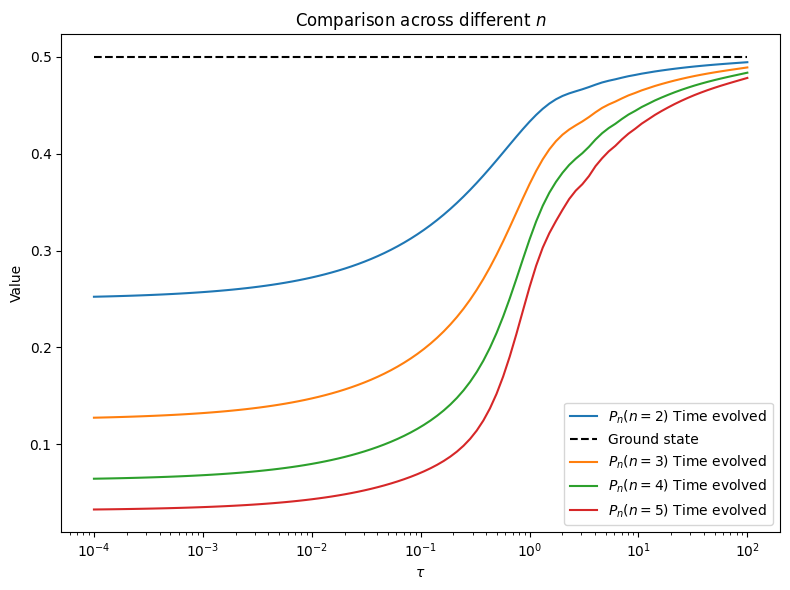

In [2]:
import numpy as np
import matplotlib.pyplot as plt

L = 100
taus = np.logspace(-4, 2, 100)
n_values = [2,3 ,4,5]
N_n = len(n_values)
N_tau = len(taus)

# Preallocate arrays
KZ_array = np.zeros((N_n, N_tau))
GS_array = np.zeros((N_n, N_tau))
Delta_array = np.zeros((N_n, N_tau))

for j, tau in tqdm(enumerate(taus)):
    t = tau
    state_t = kz.state(L, tau, t)
    k0 = kb.k_vals(L)
    U0 = kb.U(k0, -kz.g(t, tau))

    for i, n in enumerate(n_values):
        P_kz = kz.P_n(n, state_t)
        P0 = kb.P_n(n, U0, k0)
        diff = kz.delta(state_t, [U0, k0], n)

        KZ_array[i, j] = P_kz
        GS_array[i, j] = P0
        Delta_array[i, j] = diff

# Example plot
plt.figure(figsize=(8, 6))
for i, n in enumerate(n_values):
    plt.plot(taus, KZ_array[i], label=fr"$P_n(n={n})$ Time evolved")
    if i == 0:
        plt.plot(taus, GS_array[i], linestyle='--', label="Ground state", color="black")
    # plt.plot(taus, Delta_array[i], linestyle=':', label=fr"$\Delta(n={n})$")

plt.xlabel(r"$\tau$")
plt.ylabel("Value")
plt.xscale("log")
#plt.yscale("log")
plt.legend()
plt.title("Comparison across different $n$")
plt.tight_layout()
plt.show()


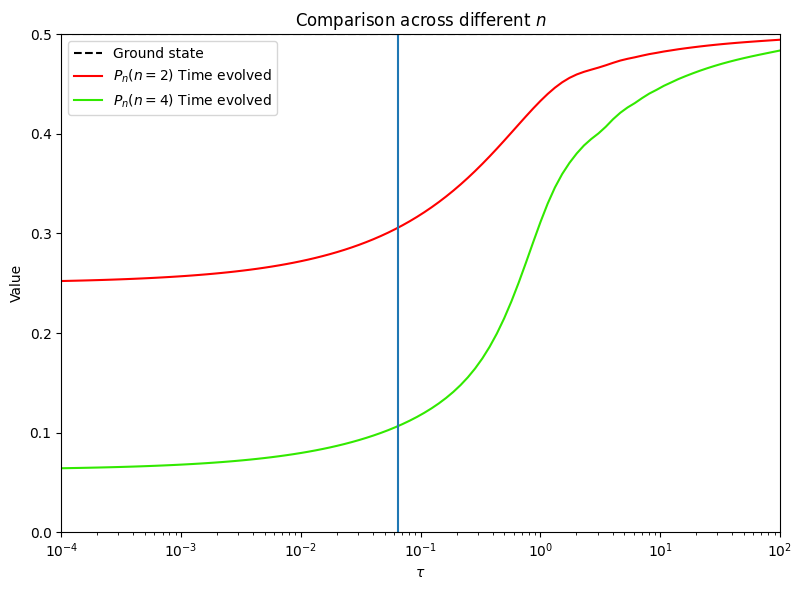

In [8]:
import matplotlib.pyplot as plt

colors = plt.cm.prism(np.linspace(0, 0.5, len(n_values)))  # or use any colormap

plt.figure(figsize=(8, 6))
for i, n in enumerate(n_values):
    color = colors[i]
    if i%2 ==0:
        if i == 0:
            #pass
            plt.plot(taus, GS_array[i], linestyle='--', label="Ground state", color="black")
        
        #h = half_max_indices[i]
        plt.plot(taus, (KZ_array[i]), label=fr"$P_n(n={n})$ Time evolved", linestyle="-", color=color)


plt.xlabel(r"$\tau$")
plt.ylabel("Value")
plt.xscale("log")
plt.legend()
plt.title("Comparison across different $n$")
plt.tight_layout()
plt.ylim(0,0.5)
plt.xlim(taus[0],taus[-1])
plt.vlines(4/2/pi/pi/pi,0,1)
plt.show()



(0.0, 1.0)

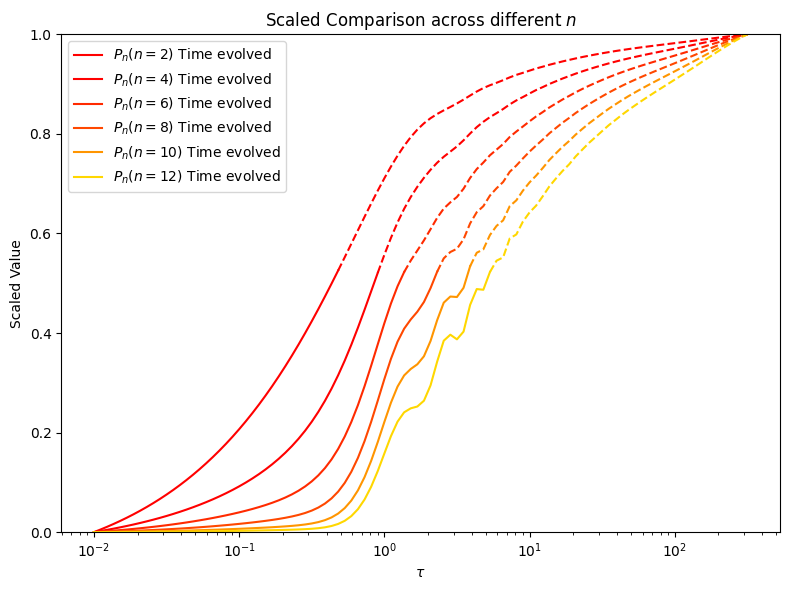

In [163]:
import matplotlib.pyplot as plt
import numpy as np

colors = plt.cm.prism(np.linspace(0, 0.5, len(n_values)))

plt.figure(figsize=(8, 6))
for i, n in enumerate(n_values):
    if i % 2 != 0:
        continue

    color = colors[i]

    # Normalize data to [0,1]
    kz = (KZ_array[i] - KZ_array[i][0]) / (KZ_array[i][-1] - KZ_array[i][0])

    # Find new halfway index where value first exceeds 0.5
    h_new = np.argmax(kz >= 0.5)

    # Plot before and after halfway
    plt.plot(taus[:h_new+1], kz[:h_new+1], label=fr"$P_n(n={n})$ Time evolved", linestyle="-", color=color)
    plt.plot(taus[h_new:], kz[h_new:], linestyle="--", color=color)

plt.xlabel(r"$\tau$")
plt.ylabel("Scaled Value")
plt.xscale("log")
plt.legend()
plt.title("Scaled Comparison across different $n$")
plt.tight_layout()
#plt.show()
plt.ylim(0,1)


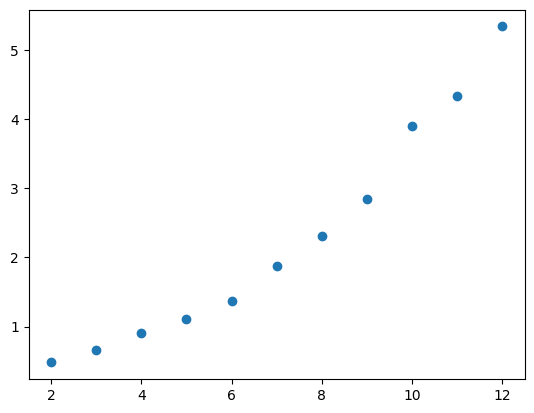

In [164]:
half_max_indices = []

for row in KZ_array:
    max_val = 0.5
    min_val = np.min(row)
    half_val = (max_val+ min_val) / 2 # midpoint between min and max
    idx = np.argmax(row >= half_val)
    half_max_indices.append(idx)

half_max_indices = np.array(half_max_indices)
half_max_indices
taus_at_half = taus[half_max_indices]
plt.scatter(n_values,taus_at_half)

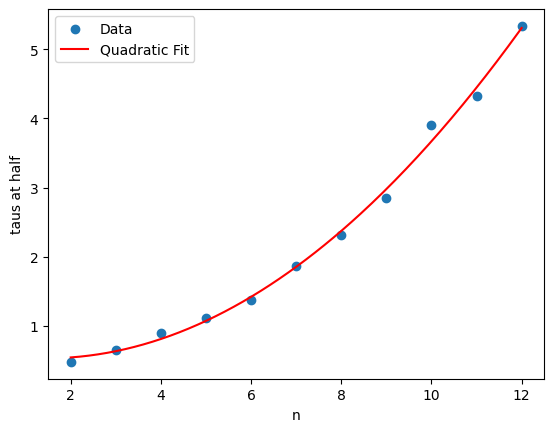

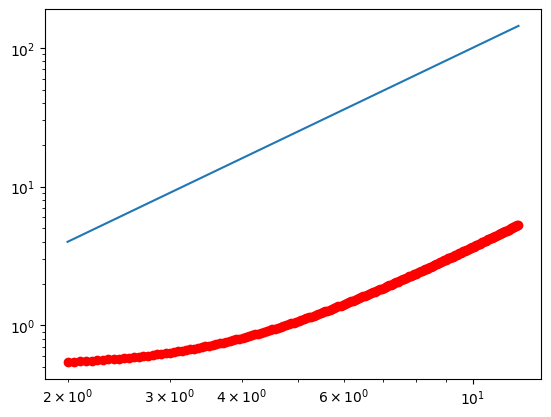

In [165]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


# Define quadratic model
def quadratic(n, a, b, c):
    return a * n**2 + b * n + c

# Fit
params, _ = curve_fit(quadratic, n_values, taus_at_half)

# Plot
plt.scatter(n_values, taus_at_half, label="Data")
n_fit = np.linspace(min(n_values), max(n_values), 200)
plt.plot(n_fit, quadratic(n_fit, *params), label="Quadratic Fit", color="red")
plt.xlabel("n")
plt.ylabel("taus at half")
plt.legend()
plt.show()

n_values=np.array(n_values)
plt.loglog(n_values,n_values**2)
plt.scatter(n_fit, quadratic(n_fit, *params), label="Quadratic Fit", color="red")


In [414]:

def sigmaz_general_U(indices,T,k):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)

    #Get string lengths
    A_coords = np.array(indices)
    B_coords = np.array(indices)
    N = len(indices)
    C = np.zeros((N,N))
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = kb.D(Nd,T,k)
    return np.linalg.det(C)
def sigmaz_general(indices,state):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Get string lengths
    A_coords = np.array(indices)
    B_coords = np.array(indices)
    N = len(indices)
    C = np.zeros((N,N))
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = kz.D(-Nd,state)
   # print(C)
    return np.linalg.det(C)
##Projector Functions 
from itertools import combinations
from collections import Counter

def binomial_expansion(indices):
    """
    Computes the pairs of combinations of indices.
    """
    pairs = list(combinations(indices, 2))
    return pairs

def all_combinations(indices):
    """
    Computes all combinations of all lengths of indices.
    """
    x = []
    for r in range(len(indices) + 1):
        x.extend(combinations(indices, r))
    return list(x)

def unique_elements_and_frequencies(vec):
    unique_vals, freqs = np.unique(vec, return_counts=True)
    return unique_vals, freqs


#Typical Pn function
def P_zn(n,state):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = kb.all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    

    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        dat.append(sigmaz_general(indices,state)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n


def P_nU(n,U,k):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = kb.all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    

    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        dat.append(sigmaz_general_U(indices,U,k)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n

0it [00:00, ?it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_31650/167524771.py:42: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_31650/167524771.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kb.D(Nd,T,k)
100it [00:32,  3.04it/s]


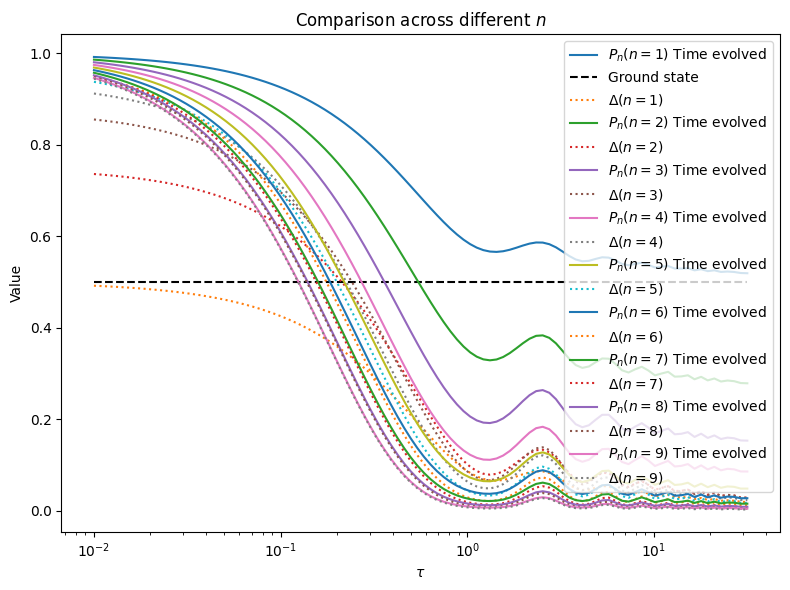

In [415]:
import numpy as np
import matplotlib.pyplot as plt

L = 100
taus = np.logspace(-2., 1.5, 100)
n_values = [1,2 ,3,4,5,6,7,8,9]
N_n = len(n_values)
N_tau = len(taus)

# Preallocate arrays
KZ_array = np.zeros((N_n, N_tau))
GS_array = np.zeros((N_n, N_tau))
Delta_array = np.zeros((N_n, N_tau))

for j, tau in tqdm(enumerate(taus)):
    t = tau
    state_t = kz.state(L, tau, t)
    k0 = kb.k_vals(L)
    U0 = kb.U(k0, -kz.g(t, tau))

    for i, n in enumerate(n_values):
        P_kz = P_zn(n, state_t)
        P0 = P_nU(n, U0, k0)
        diff = np.abs(P0-P_kz)

        KZ_array[i, j] = P_kz
        GS_array[i, j] = P0
        Delta_array[i, j] = diff

# Example plot
plt.figure(figsize=(8, 6))
for i, n in enumerate(n_values):
    plt.plot(taus, KZ_array[i], label=fr"$P_n(n={n})$ Time evolved")
    if i == 0:
        plt.plot(taus, GS_array[i], linestyle='--', label="Ground state", color="black")
    plt.plot(taus, Delta_array[i], linestyle=':', label=fr"$\Delta(n={n})$")

plt.xlabel(r"$\tau$")
plt.ylabel("Value")
plt.xscale("log")
#plt.yscale("log")
plt.legend()
plt.title("Comparison across different $n$")
plt.tight_layout()
plt.show()


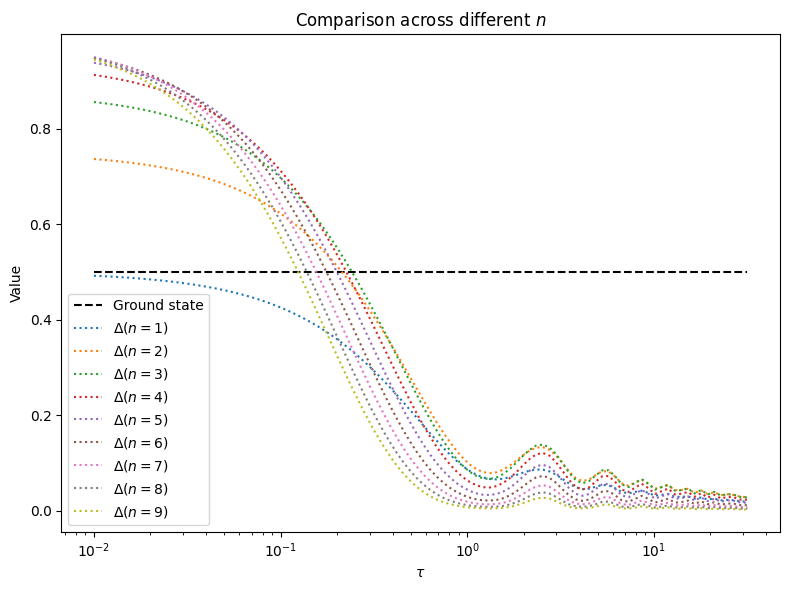

In [416]:
plt.figure(figsize=(8, 6))
for i, n in enumerate(n_values):
    #plt.plot(taus, KZ_array[i], label=fr"$P_n(n={n})$ Time evolved")
    if i == 0:
        plt.plot(taus, GS_array[i], linestyle='--', label="Ground state", color="black")
    plt.plot(taus, Delta_array[i], linestyle=':', label=fr"$\Delta(n={n})$")

plt.xlabel(r"$\tau$")
plt.ylabel("Value")
plt.xscale("log")
#plt.yscale("log")
plt.legend()
plt.title("Comparison across different $n$")
plt.tight_layout()
plt.show()

[]

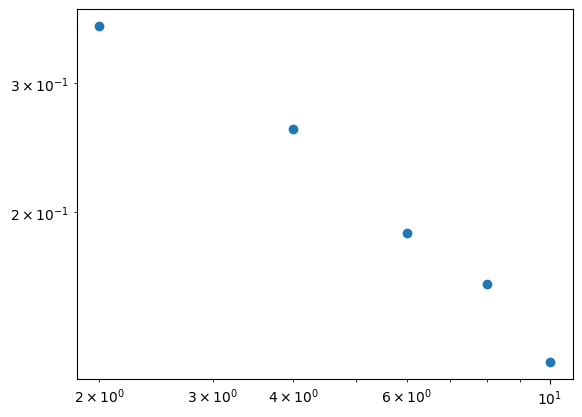

In [119]:
half_max_indices = []

for row in KZ_array:
    max_val = np.max(row)
    min_val = np.min(row)
    half_val = (max_val+ min_val) / 2 # midpoint between min and max
    idx = np.argmax(row <= half_val)
    half_max_indices.append(idx)

half_max_indices = np.array(half_max_indices)
half_max_indices
taus_at_half = taus[half_max_indices]
plt.scatter(n_values,taus_at_half)
plt.loglog()

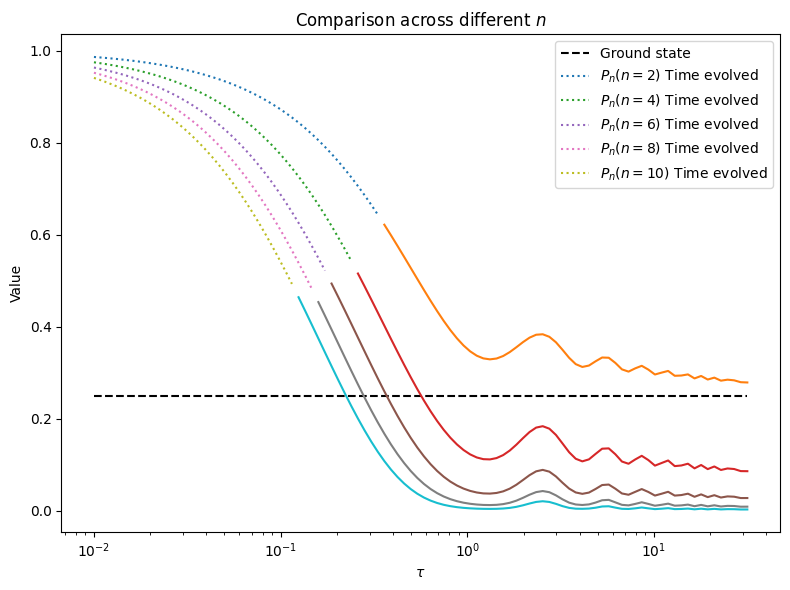

In [120]:
# Example plot
plt.figure(figsize=(8, 6))
for i, n in enumerate(n_values):
    if i == 0:
        plt.plot(taus, GS_array[i], linestyle='--', label="Ground state", color="black")
    h = half_max_indices[i]
    plt.plot(taus[:h], KZ_array[i][:h], label=fr"$P_n(n={n})$ Time evolved",ls=":")
    plt.plot(taus[h:], KZ_array[i][h:])
   
    # plt.plot(taus, Delta_array[i], linestyle=':', label=fr"$\Delta(n={n})$")

plt.xlabel(r"$\tau$")
plt.ylabel("Value")
plt.xscale("log")
#plt.yscale("log")
plt.legend()
plt.title("Comparison across different $n$")
plt.tight_layout()
plt.show()


In [328]:
L = 100
tau = 0.0000000000000000000001
t = tau
g0 = kz.g(t,tau)
kvals = kb.k_vals(L)
u_gs = kb.U(kvals,-g0)[0][kvals>0]

v_gs = kb.U(kvals,-g0)[1][kvals>0]

u_kz= np.array(kz.state(L,tau,t)[0])
v_kz= np.array(kz.state(L,tau,t)[1])
summ = 0
for i in range(len(u_gs)):
    #print(i)
    u_gs_i = u_gs[i]
    v_gs_i = v_gs[i]
    u_kz_i = u_kz[i]
    v_kz_i = v_kz[i]
    summ+=1- np.abs(np.conj(u_gs_i)*u_kz_i+np.conj(v_gs_i)*v_kz_i)**2

summ= (2*summ/L)  

print(1/summ)


2.000000000017725


In [ ]:
def inverse_defect_density(L, tau):
    t = tau
    g0 = kz.g(t, tau)
    kvals = kb.k_vals(L)
    
    u_gs = kb.U(kvals, -g0)[0][kvals > 0]
    v_gs = kb.U(kvals, -g0)[1][kvals > 0]

    u_kz = np.abs(kz.state(L, tau, t)[0])
    v_kz = np.abs(kz.state(L, tau, t)[1])

    summ = 0
    for i in range(len(u_gs)):
        u_gs_i = u_gs[i]
        v_gs_i = v_gs[i]
        u_kz_i = u_kz[i]
        v_kz_i = v_kz[i]
        summ += 1 - np.abs(np.conj(u_gs_i)*u_kz_i + np.conj(v_gs_i)*v_kz_i)**2
    
    summ = (2 * summ / L)
    return 1 / summ


(2.0, 10.0)

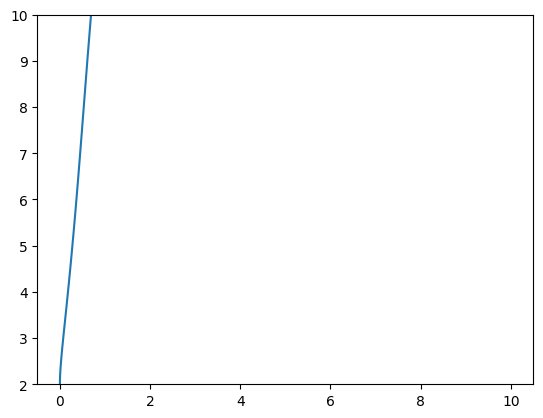

In [ ]:
n_length = [inverse_defect_density(100,tau_i) for tau_i in taus]


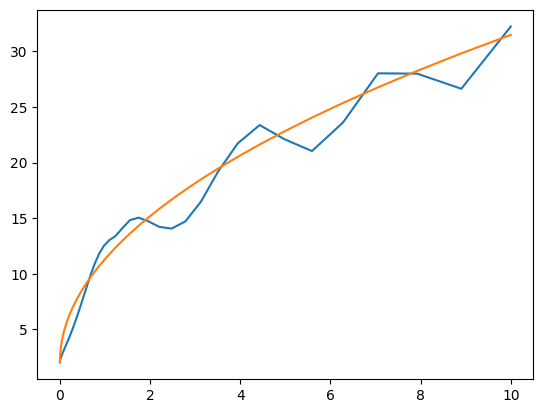

In [374]:

plot(taus,n_length)
plot(taus,pi**(1.95)*taus**(1/2)+2)




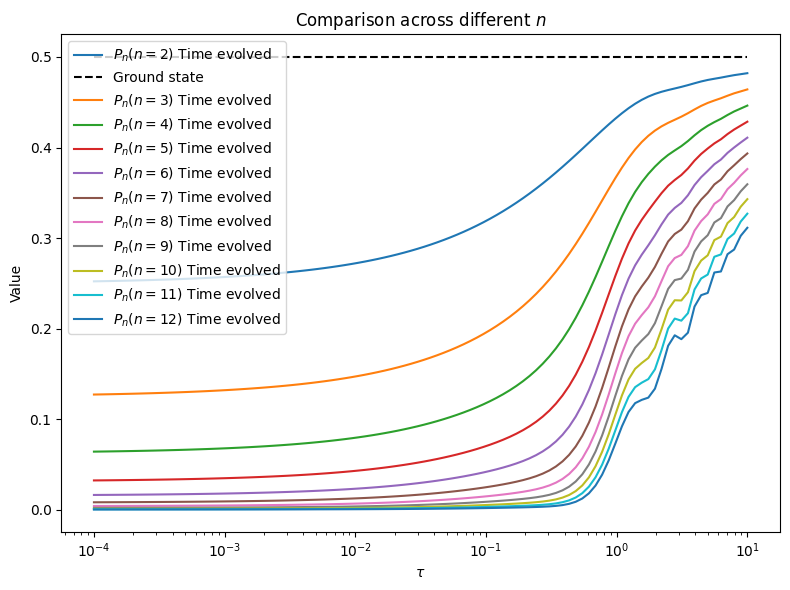

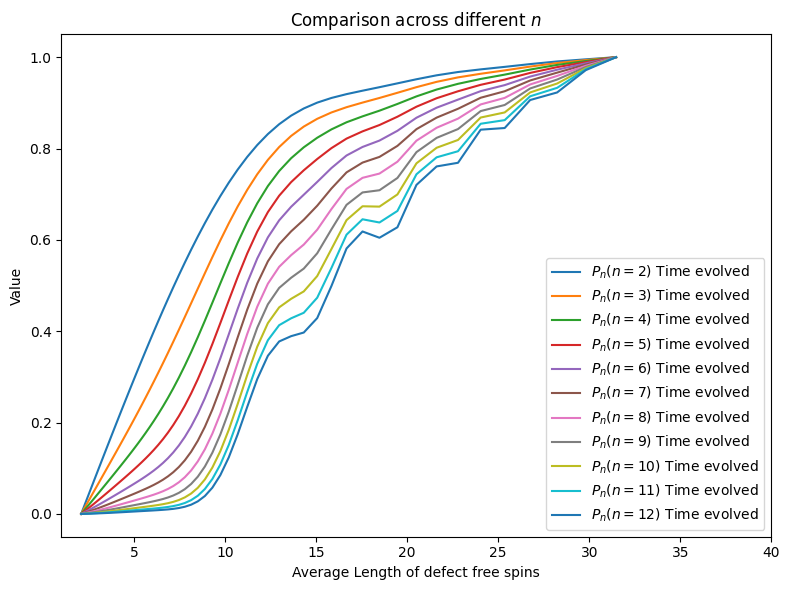

In [375]:

# Example plot
plt.figure(figsize=(8, 6))
for i, n in enumerate(n_values):
    plt.plot(taus, KZ_array[i], label=fr"$P_n(n={n})$ Time evolved")
    if i == 0:
        plt.plot(taus, GS_array[i], linestyle='--', label="Ground state", color="black")
    # plt.plot(taus, Delta_array[i], linestyle=':', label=fr"$\Delta(n={n})$")

plt.xlabel(r"$\tau$")
plt.ylabel("Value")
plt.xscale("log")
#plt.yscale("log")
plt.legend()
plt.title("Comparison across different $n$")
plt.tight_layout()
plt.show()


# Example plot
plt.figure(figsize=(8, 6))
for i, n in enumerate(n_values):
    plt.plot(pi**(1.95)*taus**(1/2)+2, (KZ_array[i]-KZ_array[i][0])/(KZ_array[i][-1]-KZ_array[i][0]), label=fr"$P_n(n={n})$ Time evolved")
    if i == 0:
        pass
       # plt.plot(n_length, GS_array[i], linestyle='--', label="Ground state", color="black")
    # plt.plot(taus, Delta_array[i], linestyle=':', label=fr"$\Delta(n={n})$")

plt.xlabel(r"Average Length of defect free spins")
plt.ylabel("Value")
plt.xlim(1,40)
#plt.xscale("log")
#plt.yscale("log")
plt.legend()
plt.title("Comparison across different $n$")
plt.tight_layout()
plt.show()

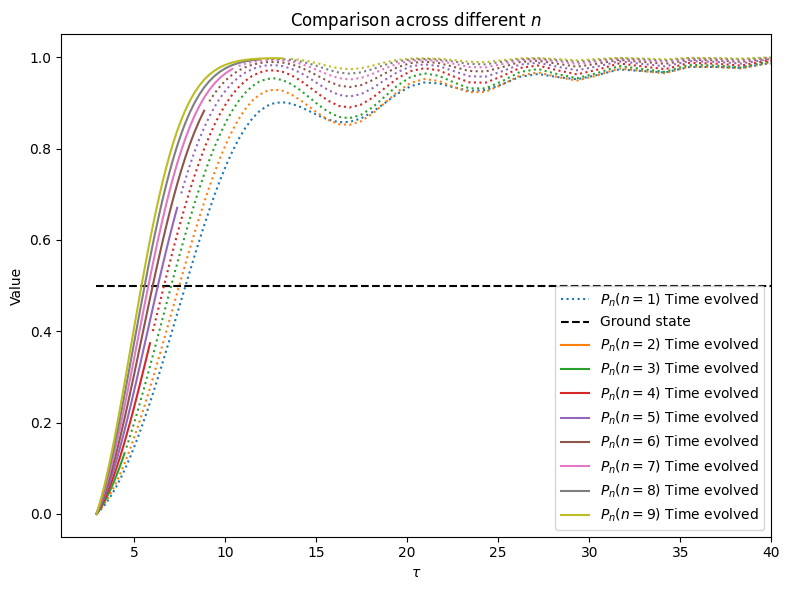

In [417]:
plt.figure(figsize=(8, 6))
for i, n in enumerate(n_values):
    xdata =pi**(1.95)*taus**(1/2)+2
    ydata = (KZ_array[i] - KZ_array[i][0]) / (KZ_array[i][-1] - KZ_array[i][0])

    # Determine cutoff index where x > n
    cutoff = np.argmax(xdata > 1.5*n)

    if cutoff == 0:
        # all x > n, plot all as dotted
        plt.plot(xdata, ydata, linestyle=':', label=fr"$P_n(n={n})$ Time evolved")
    elif cutoff == 0 and xdata[0] <= n:
        # all x <= n, plot all as solid
        plt.plot(xdata, ydata, linestyle='-', label=fr"$P_n(n={n})$ Time evolved")
    else:
        # mixed: split into two segments
        plt.plot(xdata[:cutoff], ydata[:cutoff], linestyle='-', label=fr"$P_n(n={n})$ Time evolved")
        plt.plot(xdata[cutoff:], ydata[cutoff:], linestyle=':', color=plt.gca().lines[-1].get_color())

    if i == 0:
        plt.plot(xdata, GS_array[i], linestyle='--', label="Ground state", color="black")

plt.xlabel(r"$\tau$")
plt.ylabel("Value")
plt.xlim(1, 40)
plt.legend()
plt.title("Comparison across different $n$")
plt.tight_layout()
plt.show()


In [418]:
def defect_density(L, tau):
    t = tau
    g0 = kz.g(t, tau)
    kvals = kb.k_vals(L)
    
    u_gs = kb.U(kvals, -g0)[0][kvals > 0]
    v_gs = kb.U(kvals, -g0)[1][kvals > 0]

    u_kz = np.abs(kz.state(L, tau, t)[0])
    v_kz = np.abs(kz.state(L, tau, t)[1])

    summ = 0
    for i in range(len(u_gs)):
        u_gs_i = u_gs[i]
        v_gs_i = v_gs[i]
        u_kz_i = u_kz[i]
        v_kz_i = v_kz[i]
        summ += 1 - np.abs(np.conj(u_gs_i)*u_kz_i + np.conj(v_gs_i)*v_kz_i)**2
    
    summ = (2 * summ / L)
    return summ


In [393]:
1/defect_density(L,.367)

np.float64(6.003684589691191)

28.525804541528597


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_31650/167524771.py:42: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:142: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


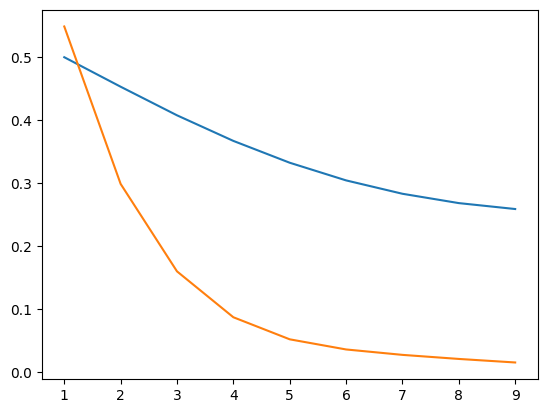

In [437]:
L= 10
tau = 1.367
print(inverse_defect_density(L,tau))
ns = [ni for ni in range(1,10)]
Z= [P_zn(ni,kz.state(L,tau,tau)) for ni in ns]
XX= [kz.P_n(ni,kz.state(L,tau,tau)) for ni in ns]
XX=np.array(XX)
plot(ns,XX)
plot(ns,Z)
#plt.yscale("log")

In [5]:
x= np.load("KZ_data_nmax=6_NTaus=_10.npy.npz")

array([1.00000000e-02, 2.78255940e-02, 7.74263683e-02, 2.15443469e-01,
       5.99484250e-01, 1.66810054e+00, 4.64158883e+00, 1.29154967e+01,
       3.59381366e+01, 1.00000000e+02])